In [7]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from typing import Callable, Optional, Tuple
from tqdm.notebook import tqdm
from pathlib import Path

from IPython.display import clear_output

from torchvision.datasets.mnist import MNIST
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import Resize, ToTensor, Normalize, Compose

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

# MNIST calculator

In this tutorial you are to implement a model that calculates the mod 10 sum of two digits in MNIST.

### Task 1. Prepare the data for the training.

Implement the `Digits` dataset class that wraps the MNIST class and augments it with the mod 10 sum of two digits.

In [ ]:
class Digits(Dataset):
    def __init__(self, root: str, train: bool = True, download: bool = True, transforms: Optional[Callable] = None):
        super(Digits, self).__init__()

        # Construct your MNIST instance here
        self.mnist = MNIST(root=root, train=train, download=download, transform=transforms)

    def __getitem__(self, idx: int) -> Tuple[torch.FloatTensor, torch.FloatTensor, int]:
        """
        Returns the datapoint at index = idx.
        You need to implement this method in such a way
        that the ith element of the Digits class
        is a pair of subsequent MNIST dataset samples.
        That is if MNIST is [a, b, c, d], then Digits
        are [[a, b], [c, d]] and the label is mod 10
        sum of the MNIST labels.

        :param idx: Index of the datapoint.
        :return: 2 image tensors, their mod 10 sum.
        """

        ##### Write your code here #####
        image_0, label_0 = self.mnist[2*idx]
        image_1, label_1 = self.mnist[2*idx+1]

        return (image_0, image_1, (label_0 + label_1) % 10)
        ################################

    def __len__(self) -> int:
        """
        Returns the length of the dataset. Equals half the length of the MNIST dataset.

        :return: The total number of datapoints in the dataset.
        """

        ##### Write your code here #####
        return len(self.mnist) // 2
        ################################

In [43]:
HERE = Path.cwd()
DATA_DIR = (HERE / ".." / ".." / "data").resolve()
DATA_TUT4_DIR = DATA_DIR / "tutorial_04"
print(DATA_TUT4_DIR)
digits = Digits(root=str(DATA_TUT4_DIR), transforms=(ToTensor()))

/Users/benjaminlabrecque/apps/home/labrecqb/unibe_deep_learning/data/tutorial_04


Construct the train and the test splits of the dataset. Leave 90% of the training set for training and the remaining 10% for the validation.

In [59]:
##### Write your code here #####
train_set, val_set, test_set = random_split(digits, lengths=[0.8, 0.1, 0.1])
################################

### Task 2. Inspect data

Visualize some datapoints.

In [60]:
##### Write your code here #####

first, second, label = train_set[0]

################################

   12


In [47]:
first.shape

torch.Size([1, 28, 28])

In [48]:
first.max()

tensor(1.)

   8


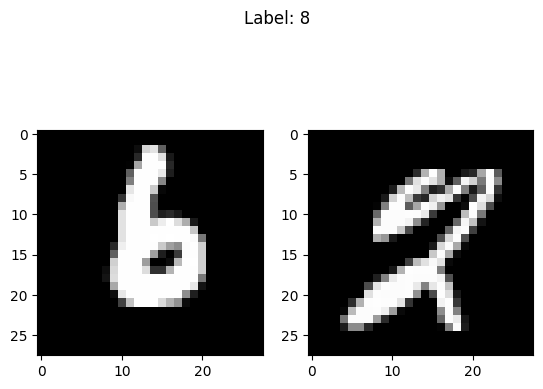

In [54]:
first, second, label = train_set[2]

ax1 = plt.subplot(1, 2, 1)
ax1.imshow(first[0], cmap="gray")

ax2 = plt.subplot(1, 2, 2)
ax2.imshow(second[0], cmap="gray")

plt.suptitle(f"Label: {label}")

plt.show()

### Task 3. Train an MLP (multi-layer perceptron).

Design and train an MLP. Consider using different
activation functions, normalization layers and dropout. Plot all the training curves.

In [ ]:
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(in_features=1568, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))  # ReLU after first linear layer
        x = F.relu(self.fc2(x))  # ReLU after second linear layer
        x = F.relu(self.fc3(x))  # ReLU after third linear layer
        return x
        

In [ ]:
def flatten(first, second):
    # first: (N, 28, 28) -> (N, 784)
    first_flat = first.view(first.size(0), -1)
    # second: (N, 28, 28) -> (N, 784)
    second_flat = second.view(second.size(0), -1)

    return torch.cat([first_flat, second_flat], dim=1)

def train_epoch(model: MLP, train_dataloader: DataLoader, optimizer, loss_fn):
    model.train()
    losses = []
    correct_predictions = 0
    # Iterate mini batches over training dataset
    for first, second, labels in tqdm(train_dataloader):
        optimizer.zero_grad()

        # concat images and pass to model
        output = model(flatten(first, second))

        loss = loss_fn(output, labels)
        loss.backward()
        optimizer.step()

        # Log metrics
        losses.append(loss.item())
        predicted_labels = output.argmax(dim=1)
        correct_predictions += (predicted_labels == labels).sum().item()
    accuracy = 100.0 * correct_predictions / len(train_dataloader.dataset)
    # Return loss values for each iteration and accuracy
    mean_loss = np.array(losses).mean()
    return mean_loss, accuracy


def evaluate(model, dataloader, loss_fn):
    """
    Compute loss on the validation or test set.
    """
    model.eval()
    loss = 0
    correct = 0
    losses = []
    with torch.no_grad():
        for first, second, labels in dataloader:
            logits = model(flatten(first, second))
            loss += loss_fn(logits, labels).item()
            pred = logits.data.max(1, keepdim=True)[1]
            correct += pred.eq(labels.data.view_as(pred)).sum()

    loss /= len(dataloader)
    losses.append(loss)
    accuracy = correct / len(dataloader.dataset)
    print(
        "\nEvaluation: Avg. loss: {:.4f}, Accuracy: {} ({:.0f}%)\n".format(
            loss,
            accuracy,
            100.0 * correct / len(dataloader.dataset),
        ),
        flush=True,
    )

    mean_loss = np.array(losses).mean()
    return mean_loss, accuracy


def train(model, train_dataloader, val_dataloader, optimizer, n_epochs, loss_function):
    # We will monitor loss functions as the training progresses
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=15,
        gamma=0.5,
    )

    for epoch in range(n_epochs):
        train_mean_loss, train_accuracy = train_epoch(
            model,
            train_dataloader,
            optimizer,
            loss_function,
        )
        validation_mean_loss, val_accuracy = evaluate(
            model, val_dataloader, loss_function
        )
        train_losses.append(train_mean_loss)
        val_losses.append(validation_mean_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        scheduler.step()


        print('Epoch {}/{}: train_loss: {:.4f}, train_accuracy: {:.4f}, val_loss: {:.4f}, val_accuracy: {:.4f}'.format(epoch+1, n_epochs,
                                                                                                      train_losses[-1],
                                                                                                      train_accuracies[-1],
                                                                                                      val_losses[-1],
                                                                                                      val_accuracies[-1]))
    return train_losses, val_losses, train_accuracies, val_accuracies


def plot(n_epochs, train_losses, val_losses, train_accuracies, val_accuracies):
    plt.figure()
    plt.plot(np.arange(n_epochs), train_losses)
    plt.plot(np.arange(n_epochs), val_losses)
    plt.legend(['train_loss', 'val_loss'])
    plt.xlabel('epoch')
    plt.ylabel('loss value')
    plt.title('Train/val loss')

    plt.figure()
    plt.plot(np.arange(n_epochs), train_accuracies)
    plt.plot(np.arange(n_epochs), val_accuracies)
    plt.legend(['train_acc', 'val_acc'])
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Train/val accuracy')





In [61]:
#make train, validation and test dataloaders

batch_size = 32

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

In [ ]:
#train the model
model = MLP()
optimizer = torch.optim.SGD(
        model.parameters(), lr=0.01, momentum=0.5, weight_decay=1e-4
    )
num_epochs = 25
train_losses, val_losses, train_accuracies, val_accuracies = train(model, train_loader, val_loader, optimizer, num_epochs, nn.CrossEntropyLoss())

ValueError: optimizer got an empty parameter list

In [ ]:
plot(num_epochs, train_losses, val_losses, train_accuracies, val_accuracies)

Evaluate your model.

In [ ]:
#using testset, evaluate the model